In [10]:
from graph.higher_dim_graph import Graph
from graph.graph import restore_from_csv
import metrics.metrics as mtx
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import powerlaw
import os
import re
import prepare
from run_maltparser import annotate
from make_graph_en import build_en_graph
from make_graph_ru import build_ru_graph
from eng_rb_anaphora import resolve_anaphora_en
from ru_rb_anaphora import resolve_anaphora_ru
import nltk
from nltk.tokenize import sent_tokenize
import string
from tqdm import tqdm

# Download required NLTK data if not present
# nltk.download("punkt_tab")


# Prepare corpus

In [11]:
def get_all_txt_files(directory):
    """
    Get all .txt files from a directory and its subdirectories.
    
    Args:
        directory (str): The root directory to search in.
    
    Returns:
        list: A list of strings, each being the content of a .txt file.
    """
    txt_contents = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.endswith('.txt'):
                file_path = os.path.join(root, file)
                try:
                    with open(file_path, 'r', encoding='utf-8') as f:
                        content = f.read()
                        txt_contents.append(content)
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")
    return txt_contents

In [12]:
def clean_angle_brackets(text):
    """
    Remove text enclosed in angle brackets <> from a string.
    
    Args:
        text (str): The input string.
    
    Returns:
        str: The cleaned string with angle bracket content removed.
    """
    return re.sub(r'<[^>]*>', '', text)

In [13]:
print(' Eng standard')
sum = 0
texsts_es = sorted(get_all_txt_files('corpus/eng_standard'), key=lambda x: len(x.split()))[:1000]
texsts_es = [' '.join(clean_angle_brackets(text).split()[:400]) for text in texsts_es]  # Truncate to first 400 words
for text in texsts_es:
    sum += len(text.split())
print(f"Number of files: {len(texsts_es)}")
print(f"Mean words in Eng standard: {sum / len(texsts_es) if texsts_es else 0}")

print('\n Ru standard')
sum = 0
texsts_rs = sorted(get_all_txt_files('corpus/ru_standard'), key=lambda x: len(x.split()))[:1000]
texsts_rs = [' '.join(clean_angle_brackets(text).split()[:700]) for text in texsts_rs]  # Truncate to first 500 words
for text in texsts_rs:
    sum += len(text.split())
print(f"Number of files: {len(texsts_rs)}")
print(f"Mean words in Ru standard: {sum / len(texsts_rs) if texsts_rs else 0}")

print('\n Eng learner')
sum = 0
texsts_el = sorted(get_all_txt_files('corpus/eng_non_standard'), key=lambda x: len(x.split()))[23000:24000]
texsts_el = [' '.join(clean_angle_brackets(text).split()[:400]) for text in texsts_el]  # Truncate to first 400 words
for text in texsts_el:
    sum += len(text.split())
print(f"Number of files: {len(texsts_el)}")
print(f"Mean words in Eng learner: {sum / len(texsts_el) if texsts_el else 0}")

print('\n Ru learner')
sum = 0
texsts_rl = sorted(get_all_txt_files('corpus/ru_non_standard'), key=lambda x: len(x.split()))[1896:]
texsts_rl = [clean_angle_brackets(text) for text in texsts_rl]  # Clean the texts
for text in texsts_rl:
    sum += len(text.split())
print(f"Number of files: {len(texsts_rl)}")
print(f"Mean words in Ru learner: {sum / len(texsts_rl) if texsts_rl else 0}")

 Eng standard
Number of files: 1000
Mean words in Eng standard: 399.427

 Ru standard
Number of files: 1000
Mean words in Ru standard: 385.431

 Eng learner
Number of files: 1000
Mean words in Eng learner: 394.187

 Ru learner
Number of files: 1000
Mean words in Ru learner: 385.806


In [25]:
print(' Eng standard')
sum = 0
texsts_es = sorted(get_all_txt_files('corpus/eng_standard'), key=lambda x: len(x.split()))[:100]
texsts_es = [' '.join(clean_angle_brackets(text).split()) for text in texsts_es]  # Truncate to first 400 words
for text in texsts_es:
    sum += len(text.split())
print(f"Number of files: {len(texsts_es)}")
print(f"Mean words in Eng standard: {sum / len(texsts_es) if texsts_es else 0}")

print('\n Ru standard')
sum = 0
texsts_rs = sorted(get_all_txt_files('corpus/ru_standard'), key=lambda x: len(x.split()))[650:750]
texsts_rs = [' '.join(clean_angle_brackets(text).split()) for text in texsts_rs]  # Truncate to first 500 words
for text in texsts_rs:
    sum += len(text.split())
print(f"Number of files: {len(texsts_rs)}")
print(f"Mean words in Ru standard: {sum / len(texsts_rs) if texsts_rs else 0}")

print('\n Eng learner')
sum = 0
texsts_el = sorted(get_all_txt_files('corpus/eng_non_standard'), key=lambda x: len(x.split()))[24000:24100]
texsts_el = [' '.join(clean_angle_brackets(text).split()) for text in texsts_el]  # Truncate to first 400 words
for text in texsts_el:
    sum += len(text.split())
print(f"Number of files: {len(texsts_el)}")
print(f"Mean words in Eng learner: {sum / len(texsts_el) if texsts_el else 0}")

print('\n Ru learner')
sum = 0
texsts_rl = sorted(get_all_txt_files('corpus/ru_non_standard'), key=lambda x: len(x.split()))[2700:2800]
texsts_rl = [clean_angle_brackets(text) for text in texsts_rl]  # Clean the texts
for text in texsts_rl:
    sum += len(text.split())
print(f"Number of files: {len(texsts_rl)}")
print(f"Mean words in Ru learner: {sum / len(texsts_rl) if texsts_rl else 0}")

 Eng standard
Number of files: 100
Mean words in Eng standard: 539.96

 Ru standard
Number of files: 100
Mean words in Ru standard: 527.49

 Eng learner
Number of files: 100
Mean words in Eng learner: 500.36

 Ru learner
Number of files: 100
Mean words in Ru learner: 531.08


In [26]:
def create_corpus_df(texts):
    """
    Create a DataFrame from a list of texts with columns 'text' and 'word_count'.
    
    Args:
        texts (list): List of strings, each being a text.
    
    Returns:
        pd.DataFrame: DataFrame with 'text' and 'word_count' columns.
    """
    word_counts = [len(text.split()) for text in texts]
    df = pd.DataFrame({'text': texts, 'word_count': word_counts})
    return df

# Create DataFrames for each balanced corpus
eng_standard_df = create_corpus_df(texsts_es)
eng_non_standard_df = create_corpus_df(texsts_el)
ru_standard_df = create_corpus_df(texsts_rs)
ru_non_standard_df = create_corpus_df(texsts_rl)

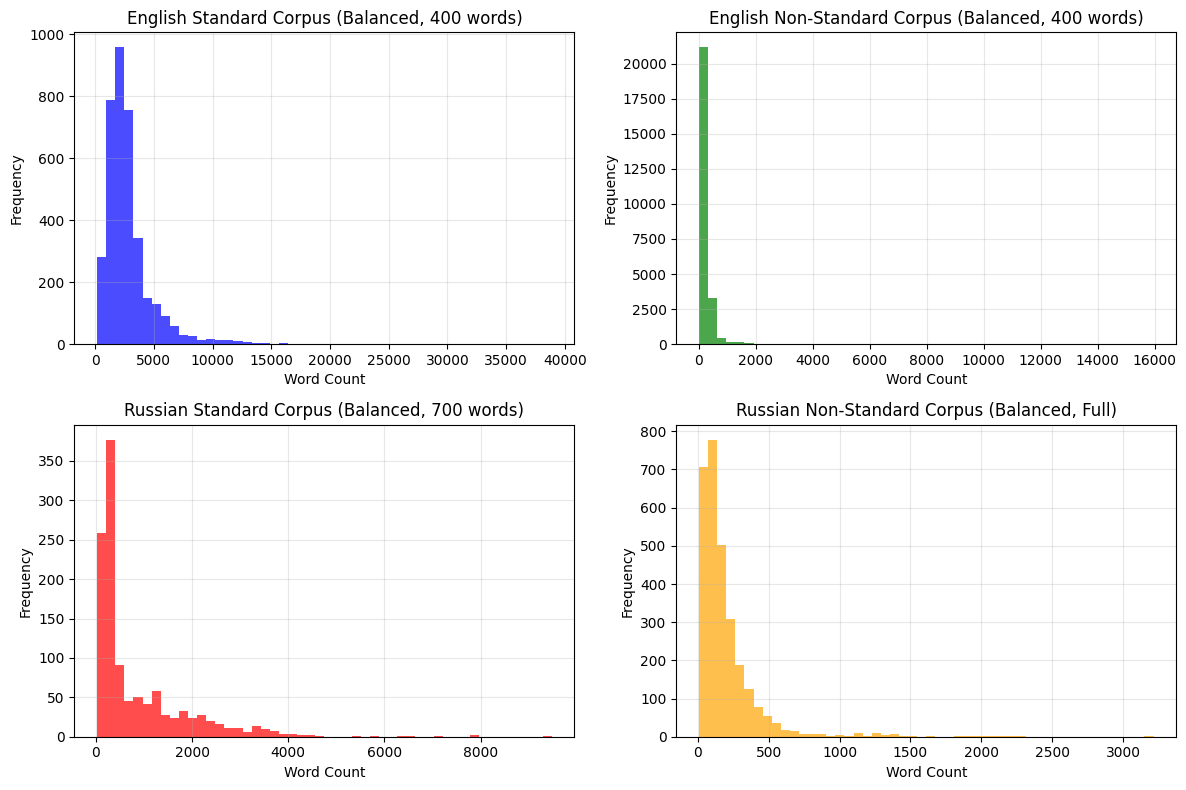

In [46]:
# Compute word counts for the balanced corpora
es_word_counts = [len(text.split()) for text in texsts_es]
el_word_counts = [len(text.split()) for text in texsts_el]
rs_word_counts = [len(text.split()) for text in texsts_rs]
rl_word_counts = [len(text.split()) for text in texsts_rl]

# For raw corpora
es_word_counts = [len(text.split()) for text in get_all_txt_files('corpus/eng_standard')]
el_word_counts = [len(text.split()) for text in get_all_txt_files('corpus/eng_non_standard')]
rs_word_counts = [len(text.split()) for text in get_all_txt_files('corpus/ru_standard')]
rl_word_counts = [len(text.split()) for text in get_all_txt_files('corpus/ru_non_standard')]

# Create 4 subplots for word count distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# English Standard
axes[0, 0].hist(es_word_counts, bins=50, alpha=0.7, color='blue')
axes[0, 0].set_title('English Standard Corpus (Balanced, 400 words)')
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# English Non-Standard (Learner)
axes[0, 1].hist(el_word_counts, bins=50, alpha=0.7, color='green')
axes[0, 1].set_title('English Non-Standard Corpus (Balanced, 400 words)')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Russian Standard
axes[1, 0].hist(rs_word_counts, bins=50, alpha=0.7, color='red')
axes[1, 0].set_title('Russian Standard Corpus (Balanced, 700 words)')
axes[1, 0].set_xlabel('Word Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# Russian Non-Standard (Learner)
axes[1, 1].hist(rl_word_counts, bins=50, alpha=0.7, color='orange')
axes[1, 1].set_title('Russian Non-Standard Corpus (Balanced, Full)')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate metrics

In [28]:
def process_text_to_graph(text, lang):
    """
    Process a text to build a graph using the pipeline.
    
    Args:
        text (str): The input text.
        lang (str): Language ('en' or 'ru').
    
    Returns:
        Graph: The built graph object.
    """
    sentences = sent_tokenize(text)
    cleaned_sentences = []
    for s in sentences:
        s = s.strip().replace("\n", " ").replace("\t", " ").lower()
        cleaned_sentences.append("".join(ch for ch in s if ch not in (string.punctuation)))
    sentences = cleaned_sentences
    input_path = "input.conll"

    with open(input_path, "w") as f:
        for sent in sentences:
            f.write(f"# text = {sent}\n")
            conll_data = prepare.sentence_to_conllx(sent, lang=lang)
            f.write(conll_data)
            f.write("\n")

    annotate("input.conll", "output.conll", lang=lang)

    if lang == 'en':
        resolved_sentences = resolve_anaphora_en("output.conll")
    elif lang == 'ru':
        resolved_sentences = resolve_anaphora_ru("output.conll")

    if lang == 'en':
        g = build_en_graph(resolved_sentences)
    else:
        g = build_ru_graph(resolved_sentences)

    return g

In [29]:
def compute_metrics_for_df(df, lang):
    """
    Compute graph and classic metrics for all texts in a DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame with 'text' column.
        lang (str): Language ('en' or 'ru').
    
    Returns:
        pd.DataFrame: DataFrame with added metric columns.
    """
    graph_metrics_list = []
    classic_metrics_list = []
    
    for text in tqdm(df['text'], desc=f"Processing {lang} texts"):
        try:
            g = process_text_to_graph(text, lang)
            graph_metrics = mtx.calculate_metrics(g)
            graph_metrics_list.append(graph_metrics)
        except Exception as e:
            print(f"Error processing graph for text: {e}")
            # Add default values
            graph_metrics_list.append({k: 0 for k in ['num_vertices', 'num_edges', 'average_degree', 'density', 'average_clustering_coefficient', 'assortativity', 'connected_components', 'giant_component_size', 'average_shortest_path_length', 'diameter', 'average_degree_centrality', 'average_betweenness_centrality', 'average_closeness_centrality', 'average_eigenvector_centrality']})
        
        lemmas = mtx.get_lemmas(text, lang)
        tokens = mtx.get_tokens(text)

        classic = {
            'classic_average_word_length': mtx.average_word_length(tokens),
            'classic_ttr': mtx.calculate_ttr(lemmas, lang),
            'classic_mtld': mtx.calculate_mtld(lemmas, lang),
            'classic_syllable_count': mtx.syllables_count(text, lang),
            'classic_average_syllables_per_word': mtx.average_syllables_per_word(text, lang),
            'classic_t_score': mtx.calculate_t_score(lemmas),
            'classic_mi': mtx.calculate_mi(lemmas),
            'classic_logdice': mtx.calculate_logdice(lemmas)
        }
        classic_metrics_list.append(classic)
    
    # Add graph metrics columns
    for key in graph_metrics_list[0].keys():
        df[f'graph_{key}'] = [m[key] for m in graph_metrics_list]
    
    # Add classic metrics columns
    for key in classic_metrics_list[0].keys():
        df[key] = [m[key] for m in classic_metrics_list]
    
    return df

In [34]:
# Compute metrics for each DataFrame
print("Computing metrics for English Standard...")
eng_standard_df = compute_metrics_for_df(eng_standard_df, 'en')

print("Computing metrics for English Non-Standard...")
eng_non_standard_df = compute_metrics_for_df(eng_non_standard_df, 'en')

print("Computing metrics for Russian Standard...")
ru_standard_df = compute_metrics_for_df(ru_standard_df, 'ru')

print("Computing metrics for Russian Non-Standard...")
ru_non_standard_df = compute_metrics_for_df(ru_non_standard_df, 'ru')

print("Metrics computation completed.")

Computing metrics for English Standard...


Processing en texts:   0%|          | 0/100 [00:00<?, ?it/s]-----------------------------------------------------------------------------
                          MaltParser 1.9.2                             
-----------------------------------------------------------------------------
         MALT (Models and Algorithms for Language Technology) Group          
             Vaxjo University and Uppsala University                         
                             Sweden                                          
-----------------------------------------------------------------------------

Started: Thu Apr 23 17:47:21 MSK 2026
  Transition system    : Projective
  Parser configuration : Stack
  Data Format          : /engmalt.linear-1.7/conllx.xml
.          	      1	      2s	    249MB
.          	     10	      2s	    253MB
           	     14	      2s	    254MB
Parsing time: 00:00:02 (2111 ms)
Finished: Thu Apr 23 17:47:23 MSK 2026
Processing en texts:   1%|          | 1/100 [00:0

Error processing graph for text: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 100 iterations')


-----------------------------------------------------------------------------
                          MaltParser 1.9.2                             
-----------------------------------------------------------------------------
         MALT (Models and Algorithms for Language Technology) Group          
             Vaxjo University and Uppsala University                         
                             Sweden                                          
-----------------------------------------------------------------------------

Started: Thu Apr 23 17:47:36 MSK 2026
  Transition system    : Projective
  Parser configuration : Stack
  Data Format          : /engmalt.linear-1.7/conllx.xml
.          	      1	      2s	    249MB
.          	     10	      2s	    250MB
           	     27	      2s	    255MB
Parsing time: 00:00:02 (2135 ms)
Finished: Thu Apr 23 17:47:38 MSK 2026
Processing en texts:   3%|▎         | 3/100 [00:18<10:38,  6.59s/it]

Error processing graph for text: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 100 iterations')


...

Error processing graph for text: max() arg is an empty sequence


-----------------------------------------------------------------------------
                          MaltParser 1.9.2                             
-----------------------------------------------------------------------------
         MALT (Models and Algorithms for Language Technology) Group          
             Vaxjo University and Uppsala University                         
                             Sweden                                          
-----------------------------------------------------------------------------

Started: Thu Apr 23 19:31:48 MSK 2026
  Transition system    : Arc-Eager
  Parser configuration : Nivre with allow_root=true, allow_reduce=false and enforce_tree=false
  Data Format          : /russian/conllx.xml
.          	      1	      2s	    274MB
.          	     10	      2s	    276MB
           	     32	      2s	    282MB
Parsing time: 00:00:02 (2601 ms)
Finished: Thu Apr 23 19:31:51 MSK 2026
Processing ru texts:   4%|▍         | 4/100 [03:02<1:16:1

Error processing graph for text: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 100 iterations')


Processing ru texts:   5%|▌         | 5/100 [03:59<1:15:44, 47.84s/it]


KeyboardInterrupt: 

In [35]:
eng_standard_df.to_pickle("eng_standard_df_test.pkl")
eng_standard_df.to_csv("eng_standard_df_test.csv", index=False)

eng_non_standard_df.to_pickle("eng_non_standard_df_test.pkl")
eng_non_standard_df.to_csv("eng_non_standard_df_test.csv", index=False)

ru_standard_df.to_pickle("ru_standard_df_test.pkl")
ru_standard_df.to_csv("ru_standard_df_test.csv", index=False)

# ru_non_standard_df.to_pickle("ru_non_standard_df_test.pkl")
# ru_non_standard_df.to_csv("ru_non_standard_df_test.csv", index=False)

In [30]:
# load pickle
eng_s_df = pd.read_pickle("eng_standard_df.pkl")
eng_s_df

,text,word_count,graph_num_vertices,graph_num_edges,graph_average_degree,graph_density,graph_average_clustering_coefficient,graph_assortativity,graph_connected_components,graph_giant_component_size,graph_average_shortest_path_length,graph_diameter,graph_average_degree_centrality,graph_average_betweenness_centrality,graph_average_closeness_centrality,graph_average_eigenvector_centrality,classic_average_word_length,classic_ttr,classic_mtld,classic_average_syllables_per_word
0,Section : NEWS # Mental health referrals for e...,162,0,0,0.000000,0.000000,0.000000,0.000000,0,0,0.000000,0,0.000000,0.000000,0.000000,0.000000,5.037313,0.671642,109.567261,1.873134
1,MICUSP Version 1.0 - PHY.G2.05.1 - Physics - S...,240,20,18,1.800000,0.094737,0.000000,-0.600000,16,4,1.500000,2,0.021053,0.000877,0.027368,0.096595,5.451613,0.139785,37.200000,2.000000
2,MICUSP Version 1.0 - PHI.G0.06.5 - Philosophy ...,316,58,32,1.103448,0.019359,0.044335,-0.059274,33,18,3.013072,7,0.017544,0.003360,0.038414,0.056724,4.453074,0.466019,40.950899,1.812298
3,Question 1: Newton Raphson(a) FORMULA ; FORMUL...,335,56,164,5.857143,0.106494,0.359704,-0.130669,13,42,3.033682,7,0.051299,0.021056,0.194952,0.076347,4.558824,0.343137,22.390190,1.803922
4,Jessica is 14 and lives with her mum and siste...,374,46,27,1.173913,0.026087,0.047101,-0.259259,25,7,2.142857,4,0.021256,0.000966,0.029591,0.051067,4.132979,0.425532,62.666667,1.550532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Ebbinghaus can be credited as one of the found...,400,68,148,4.352941,0.064969,0.463578,0.031621,11,50,3.706939,9,0.051800,0.022082,0.156168,0.065919,5.268542,0.524297,71.683333,1.959079
996,Executive SummaryThis experiment involved load...,400,63,165,5.238095,0.084485,0.434898,-0.058604,10,51,2.843922,6,0.062468,0.019743,0.239200,0.074534,5.110831,0.392947,39.700000,1.937028
997,SummaryThis investigation assesses the usefuln...,400,0,0,0.000000,0.000000,0.000000,0.000000,0,0,0.000000,0,0.000000,0.000000,0.000000,0.000000,5.503778,0.443325,63.048498,2.118388
998,IntroductionOne of the main problems facing Br...,400,94,164,3.489362,0.037520,0.382088,-0.039533,17,77,4.379016,10,0.031572,0.024586,0.159911,0.056324,4.941026,0.497436,68.174625,1.848718


In [43]:
def correlation_analysis(df, df_name):
    """
    Perform correlation analysis between graph and classic metrics in a DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame containing graph and classic metric columns.
        df_name (str): Name of the DataFrame for labeling purposes.
    
    Returns:
        pd.DataFrame: Correlation matrix between graph and classic metrics.
    """
    metric_cols = [col for col in df.columns if col.startswith('graph_') or col.startswith('classic_')]
    corr = df[metric_cols].corr()

    graph_cols = [col for col in metric_cols if col.startswith('graph_')]
    classic_cols = [col for col in metric_cols if col.startswith('classic_')]

    corr_between = corr.loc[graph_cols, classic_cols]
    print(f'Graph vs Classic metric correlations for {df_name}:')
    print('-' * 80)
    print(corr_between.round(3))

    print('\nSummary:')
    print(f"Mean absolute correlation: {corr_between.abs().values.flatten().mean():.3f}")
    print(f"Max absolute correlation: {corr_between.abs().values.flatten().max():.3f}")
    print(f"Min absolute correlation: {corr_between.abs().values.flatten().min():.3f}")

    # Heatmap
    plt.figure(figsize=(10, 8))
    plt.imshow(corr_between, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(label='Correlation')
    plt.xticks(ticks=np.arange(len(classic_cols)), labels=classic_cols, rotation=45, ha='right')
    plt.yticks(ticks=np.arange(len(graph_cols)), labels=graph_cols)
    plt.title(f'Heatmap of Graph vs Classic Metric Correlations ({df_name})')
    plt.tight_layout()
    plt.show()

    # Optionally display top correlations
    corr_flat = corr_between.abs().stack().sort_values(ascending=False)
    print('\nTop 10 strongest correlations:')
    for i, ((g_col, c_col), val) in enumerate(corr_flat.head(10).items(), start=1):
        print(f"{i}. {g_col} <-> {c_col}: {corr_between.loc[g_col, c_col]:.3f}")

Graph vs Classic metric correlations for English Standard:
--------------------------------------------------------------------------------
                                      classic_average_word_length  \
graph_num_vertices                                          0.170   
graph_num_edges                                             0.075   
graph_average_degree                                       -0.050   
graph_density                                              -0.136   
graph_average_clustering_coefficient                        0.022   
graph_assortativity                                         0.047   
graph_connected_components                                  0.101   
graph_giant_component_size                                  0.107   
graph_average_shortest_path_length                          0.005   
graph_diameter                                              0.014   
graph_average_degree_centrality                            -0.165   
graph_average_betweenness_centra

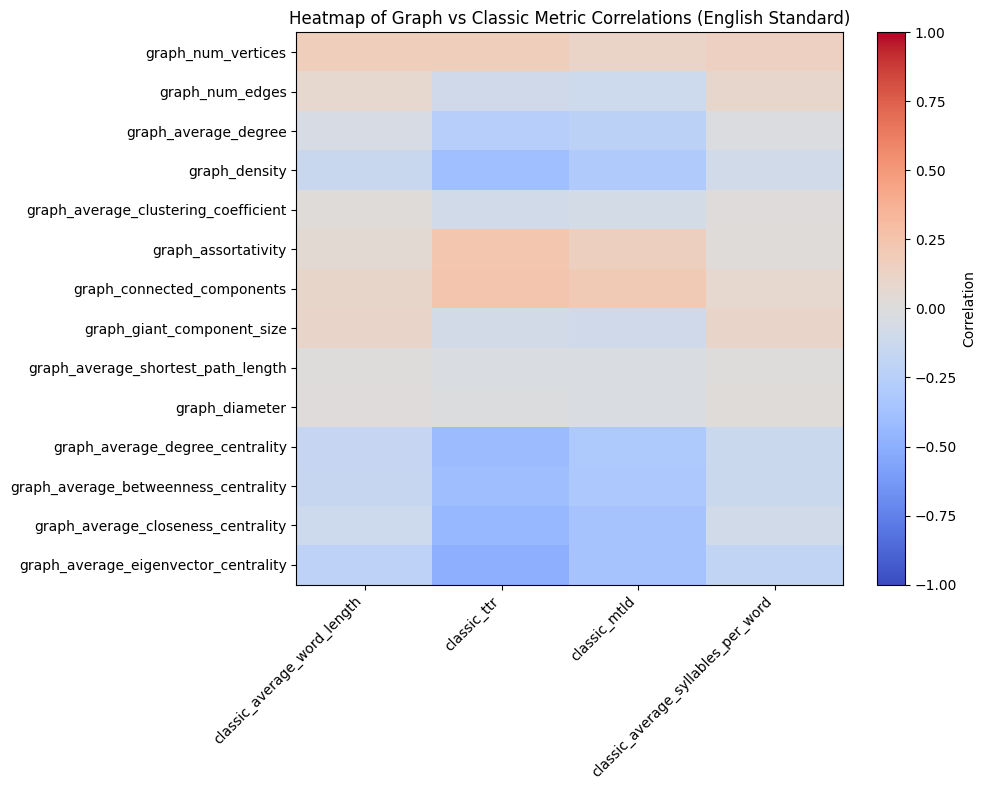


Top 10 strongest correlations:
1. graph_average_eigenvector_centrality <-> classic_ttr: -0.493
2. graph_average_closeness_centrality <-> classic_ttr: -0.438
3. graph_average_degree_centrality <-> classic_ttr: -0.416
4. graph_average_betweenness_centrality <-> classic_ttr: -0.393
5. graph_density <-> classic_ttr: -0.389
6. graph_average_closeness_centrality <-> classic_mtld: -0.357
7. graph_average_eigenvector_centrality <-> classic_mtld: -0.355
8. graph_average_betweenness_centrality <-> classic_mtld: -0.315
9. graph_average_degree_centrality <-> classic_mtld: -0.310
10. graph_density <-> classic_mtld: -0.289


In [44]:
correlation_analysis(eng_s_df, 'English Standard')

Graph vs Classic metric correlations for English Standard Test:
--------------------------------------------------------------------------------
                                      classic_average_word_length  \
graph_num_vertices                                          0.080   
graph_num_edges                                             0.130   
graph_average_degree                                       -0.038   
graph_density                                              -0.218   
graph_average_clustering_coefficient                        0.040   
graph_assortativity                                         0.187   
graph_connected_components                                  0.115   
graph_giant_component_size                                 -0.004   
graph_average_shortest_path_length                         -0.101   
graph_diameter                                             -0.109   
graph_average_degree_centrality                            -0.177   
graph_average_betweenness_c

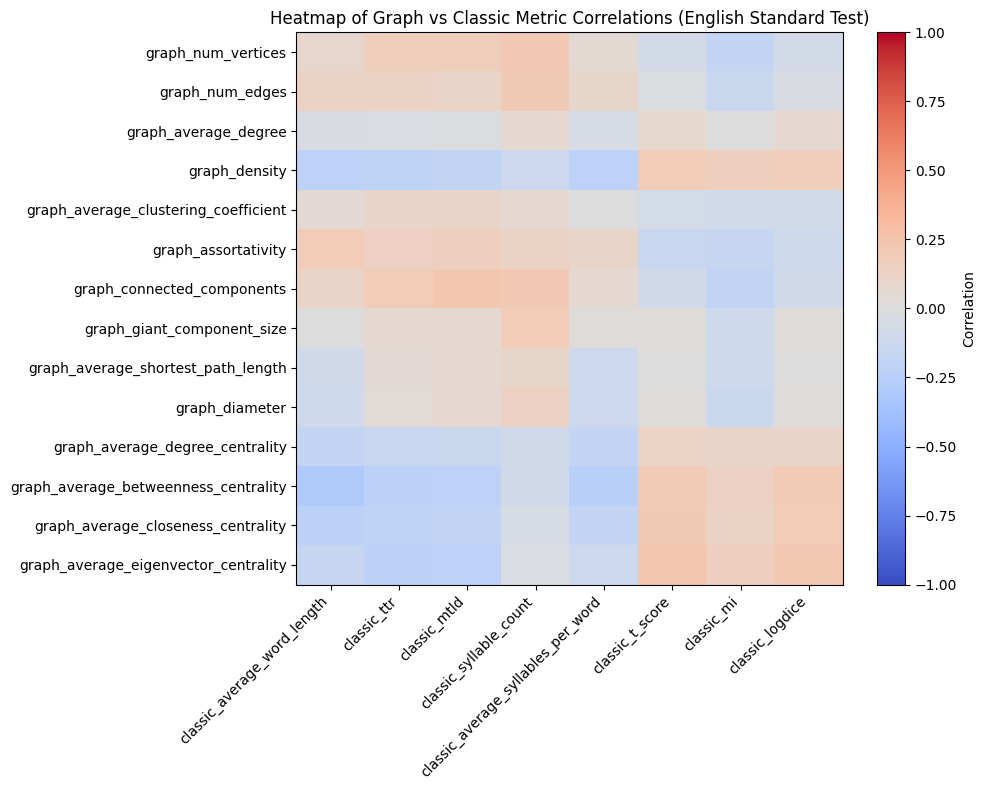


Top 10 strongest correlations:
1. graph_average_betweenness_centrality <-> classic_average_word_length: -0.303
2. graph_average_betweenness_centrality <-> classic_average_syllables_per_word: -0.246
3. graph_average_eigenvector_centrality <-> classic_t_score: 0.242
4. graph_connected_components <-> classic_mtld: 0.231
5. graph_average_betweenness_centrality <-> classic_ttr: -0.224
6. graph_average_eigenvector_centrality <-> classic_ttr: -0.221
7. graph_average_closeness_centrality <-> classic_average_word_length: -0.221
8. graph_density <-> classic_average_word_length: -0.218
9. graph_average_betweenness_centrality <-> classic_mtld: -0.216
10. graph_density <-> classic_average_syllables_per_word: -0.215


In [45]:
test_eng_s_df = pd.read_csv("eng_standard_df_test.csv")
correlation_analysis(test_eng_s_df, 'English Standard Test')

Graph vs Classic metric correlations for eng_s_df:
--------------------------------------------------------------------------------
                                      classic_average_word_length  \
graph_num_vertices                                          0.059   
graph_num_edges                                            -0.010   
graph_average_degree                                       -0.096   
graph_density                                              -0.175   
graph_average_clustering_coefficient                       -0.058   
graph_assortativity                                         0.020   
graph_connected_components                                  0.104   
graph_giant_component_size                                 -0.001   
graph_average_shortest_path_length                         -0.041   
graph_diameter                                             -0.030   
graph_average_degree_centrality                            -0.166   
graph_average_betweenness_centrality    

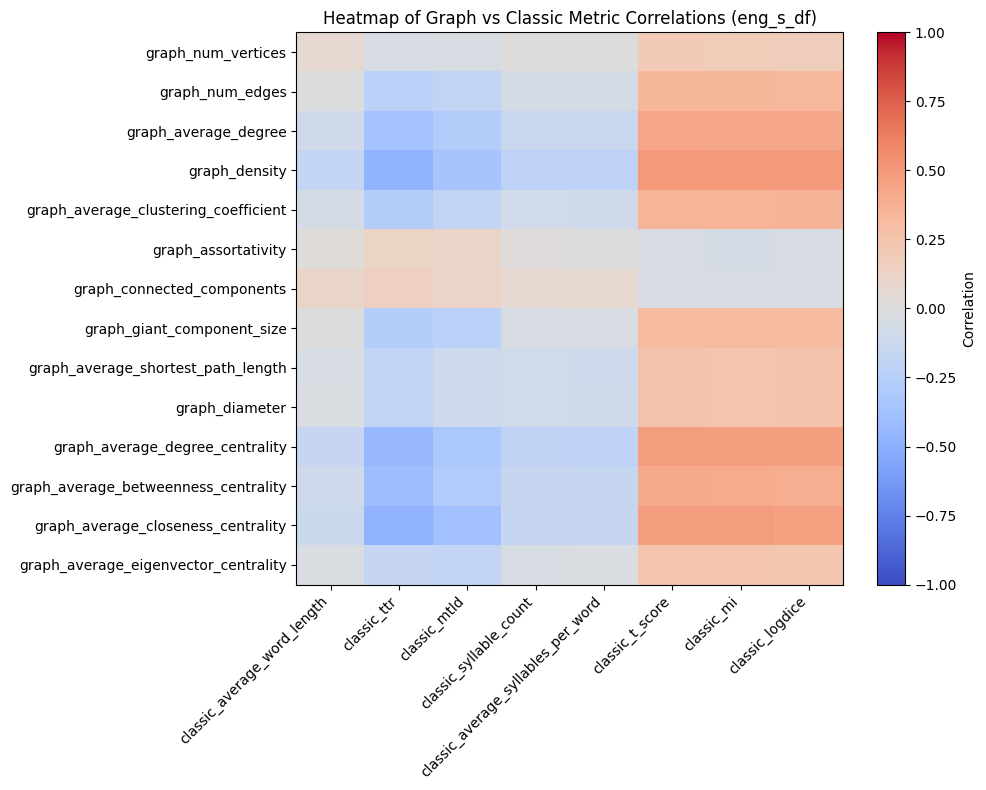


Top 10 strongest correlations:
1. graph_density <-> classic_t_score: 0.493
2. graph_density <-> classic_mi: 0.489
3. graph_density <-> classic_logdice: 0.487
4. graph_average_closeness_centrality <-> classic_mi: 0.478
5. graph_average_degree_centrality <-> classic_t_score: 0.476
6. graph_average_closeness_centrality <-> classic_t_score: 0.473
7. graph_average_degree_centrality <-> classic_mi: 0.472
8. graph_average_degree_centrality <-> classic_logdice: 0.472
9. graph_average_closeness_centrality <-> classic_ttr: -0.466
10. graph_average_closeness_centrality <-> classic_logdice: 0.465


In [39]:
test_eng_ns_df = pd.read_csv("eng_non_standard_df_test.csv")
correlation_analysis(test_eng_ns_df)

Graph vs Classic metric correlations for eng_s_df:
--------------------------------------------------------------------------------
                                      classic_average_word_length  \
graph_num_vertices                                          0.092   
graph_num_edges                                            -0.004   
graph_average_degree                                       -0.158   
graph_density                                              -0.317   
graph_average_clustering_coefficient                       -0.321   
graph_assortativity                                         0.116   
graph_connected_components                                  0.075   
graph_giant_component_size                                  0.070   
graph_average_shortest_path_length                          0.023   
graph_diameter                                              0.045   
graph_average_degree_centrality                            -0.296   
graph_average_betweenness_centrality    

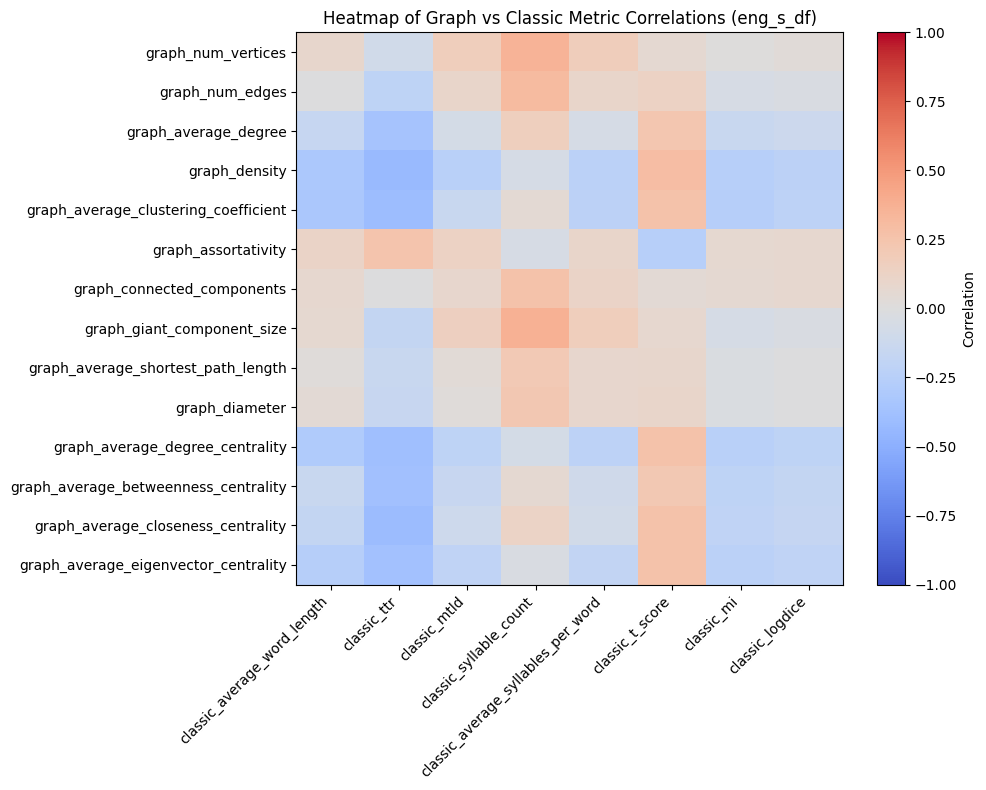


Top 10 strongest correlations:
1. graph_density <-> classic_ttr: -0.422
2. graph_average_closeness_centrality <-> classic_ttr: -0.410
3. graph_average_clustering_coefficient <-> classic_ttr: -0.405
4. graph_average_degree_centrality <-> classic_ttr: -0.383
5. graph_average_betweenness_centrality <-> classic_ttr: -0.382
6. graph_average_eigenvector_centrality <-> classic_ttr: -0.369
7. graph_giant_component_size <-> classic_syllable_count: 0.367
8. graph_num_vertices <-> classic_syllable_count: 0.356
9. graph_average_degree <-> classic_ttr: -0.352
10. graph_average_clustering_coefficient <-> classic_average_word_length: -0.321


In [40]:
test_ru_s_df = pd.read_csv("ru_standard_df_test.csv")
correlation_analysis(test_ru_s_df)